<a href="https://colab.research.google.com/github/31-10-05/ml-project/blob/main/best_selling_book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seaborn verion 0.13.2
list of punctuations :  !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


/tmp/ipython-input-34-3837001465.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(best_nf_authors.index, fontsize = 12, fontweight = 'semibold')
/tmp/ipython-input-34-3837001465.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(best_f_authors.index, fontsize=12, fontweight = 'semibold')


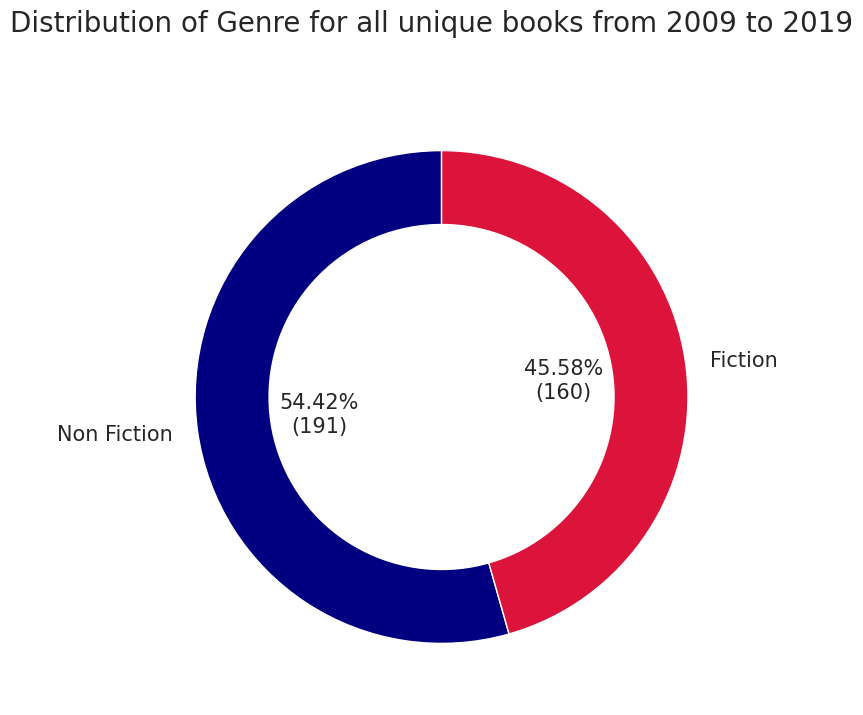

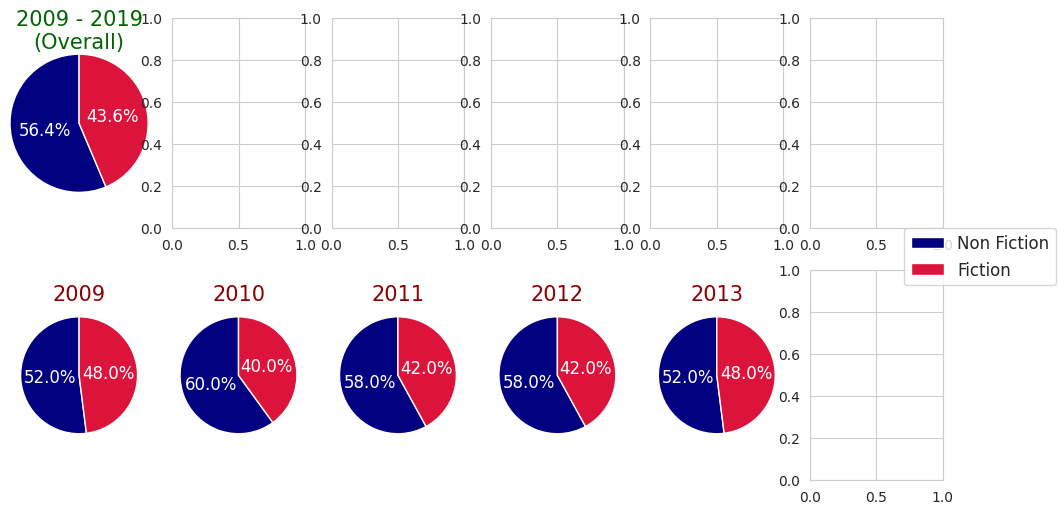

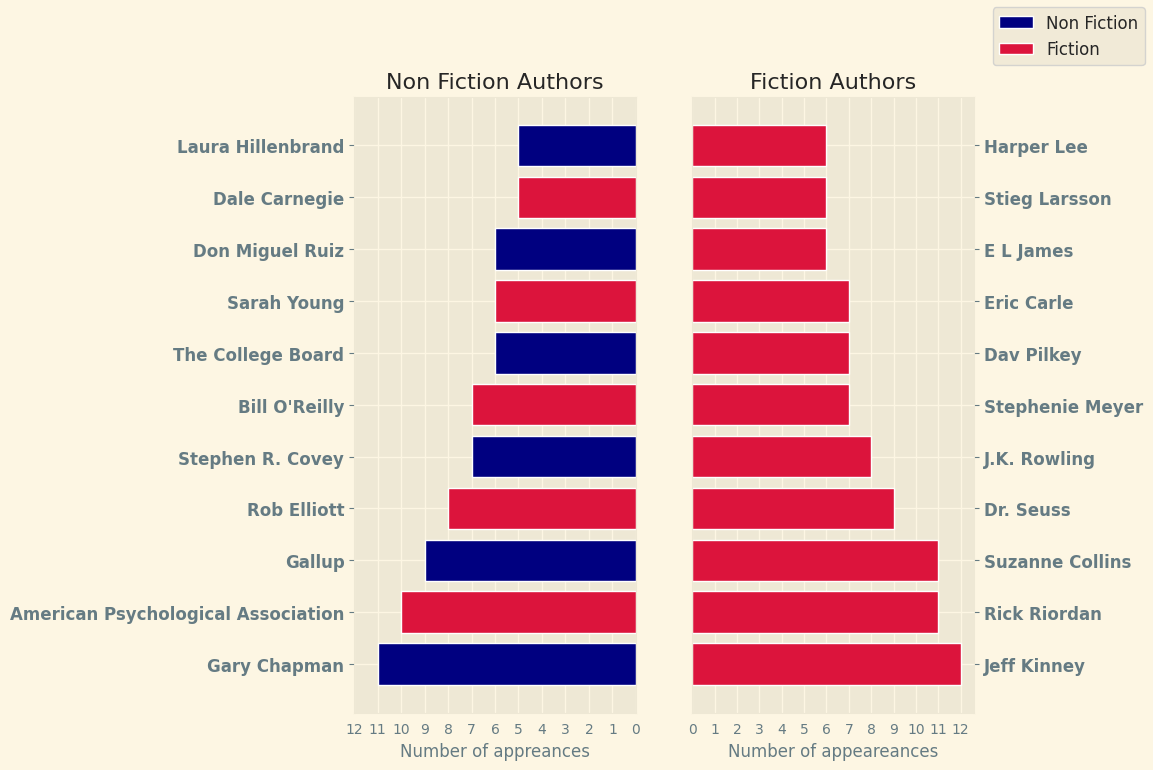

/tmp/ipython-input-34-3837001465.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(top_authors.index, fontweight='semibold')


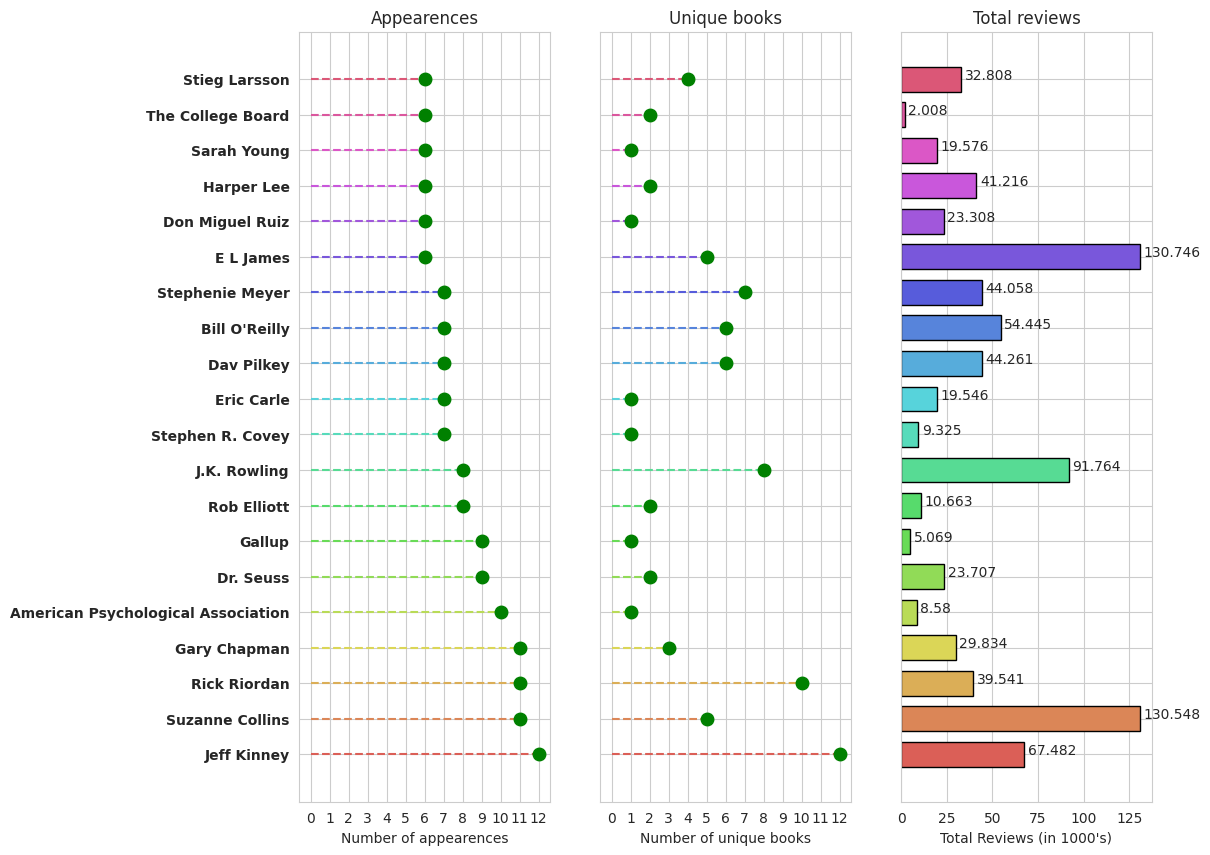

In [34]:
import pandas as pd # dataframe manipulation
import numpy as np # linear algebra

# data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print('Seaborn verion', sns.__version__)
sns.set_style('whitegrid')

# text data
import string
import re
df = pd.read_csv('bestsellers with categories.csv')

df.rename(columns={"User Rating": "User_Rating"}, inplace=True)
df[df.Author == 'J. K. Rowling']
df[df.Author == 'J.K. Rowling']
df.loc[df.Author == 'J. K. Rowling', 'Author'] = 'J.K. Rowling'
df['name_len'] = df['Name'].apply(lambda x: len(x) - x.count(" ")) # subtract whitespaces
punctuations = string.punctuation
print('list of punctuations : ', punctuations)

# percentage of punctuations
def count_punc(text):
    """This function counts the number of punctuations in a text"""
    count = sum(1 for char in text if char in punctuations)
    return round(count/(len(text) - text.count(" "))*100, 3)

# apply function
df['punc%'] = df['Name'].apply(lambda x: count_punc(x))

no_dup = df.drop_duplicates('Name')
g_count = no_dup['Genre'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

genre_col = ['navy','crimson']
#genre_col = ['khaki','plum']

center_circle = plt.Circle((0, 0), 0.7, color='white')
plt.pie(x=g_count.values, labels=g_count.index, autopct=make_autopct(g_count.values),
          startangle=90, textprops={'size': 15}, pctdistance=0.5, colors=genre_col)
ax.add_artist(center_circle)

fig.suptitle('Distribution of Genre for all unique books from 2009 to 2019', fontsize=20)
fig.show()

#visualize according to each year
y1 = np.arange(2009, 2014)
y2 = np.arange(2014, 2020)
g_count = df['Genre'].value_counts()

fig, ax = plt.subplots(2, 6, figsize = (12,6))

ax[0,0].pie(x=g_count.values, labels = None, autopct = '%1.1f%%',
            startangle = 90, textprops = {'size': 12, 'color': 'white'},
            pctdistance = 0.5, radius = 1.3, colors = genre_col)
ax[0,0].set_title('2009 - 2019\n(Overall)', color = 'darkgreen', fontdict = {'fontsize': 15})

for i, year in enumerate(y1):
  counts = df[df['Year'] == year]['Genre'].value_counts()
  ax[1,i].pie(x=counts.values, labels = None, autopct = '%1.1f%%',
              startangle = 90, textprops = {'size': 12, 'color': 'white'},
              pctdistance = 0.5, colors = genre_col, radius = 1.1)
  ax[1,i].set_title(year, color = 'darkred', fontdict = {'fontsize': 15})

fig.legend(g_count.index, loc='center right', fontsize = 12)
fig.show()

best_nf_authors = df.groupby(['Author', 'Genre']).agg({'Name': 'count'}).unstack()['Name', 'Non Fiction'].sort_values(ascending = False)[:11]
best_f_authors = df.groupby(['Author', 'Genre']).agg({'Name': 'count'}).unstack()['Name', 'Fiction'].sort_values(ascending = False)[:11]

with plt.style.context('Solarize_Light2'):
  fig,  ax = plt.subplots(1, 2, figsize=(8,8))

  ax[0].barh(y=best_nf_authors.index, width = best_nf_authors.values,
             color = genre_col)
  ax[0].invert_xaxis()
  ax[0].yaxis.tick_left()
  ax[0].set_xticks(np.arange(max(best_f_authors.values)+1))
  ax[0].set_yticklabels(best_nf_authors.index, fontsize = 12, fontweight = 'semibold')
  ax[0].set_xlabel('Number of appreances')
  ax[0].set_title('Non Fiction Authors')

  ax[1].barh(y=best_f_authors.index, width = best_f_authors.values,
             color = genre_col[1])
  ax[1].yaxis.tick_right()
  ax[1].set_xticks(np.arange(max(best_f_authors.values)+1))
  ax[1].set_yticklabels(best_f_authors.index, fontsize=12, fontweight = 'semibold')
  ax[1].set_title('Fiction Authors')
  ax[1].set_xlabel('Number of appeareances')

  fig.legend(['Non Fiction', 'Fiction'], fontsize = 12)

plt.show()

n_best = 20

top_authors = df.Author.value_counts().nlargest(n_best)
no_dup = df.drop_duplicates('Name') # removes all rows with duplicate book names

fig, ax = plt.subplots(1, 3, figsize=(11,10), sharey=True)

color = sns.color_palette("hls", n_best)

ax[0].hlines(y=top_authors.index , xmin=0, xmax=top_authors.values, color=color, linestyles='dashed')
ax[0].plot(top_authors.values, top_authors.index, 'go', markersize=9)
ax[0].set_xlabel('Number of appearences')
ax[0].set_xticks(np.arange(top_authors.values.max()+1))
ax[0].set_yticklabels(top_authors.index, fontweight='semibold')
ax[0].set_title('Appearences')

book_count = []
total_reviews = []
for name, col in zip(top_authors.index, color):
    book_count.append(len(no_dup[no_dup.Author == name]['Name']))
    total_reviews.append(no_dup[no_dup.Author == name]['Reviews'].sum()/1000)
ax[1].hlines(y=top_authors.index , xmin=0, xmax=book_count, color=color, linestyles='dashed')
ax[1].plot(book_count, top_authors.index, 'go', markersize=9)
ax[1].set_xlabel('Number of unique books')
ax[1].set_xticks(np.arange(max(book_count)+1))
ax[1].set_title('Unique books')

ax[2].barh(y=top_authors.index, width=total_reviews, color=color, edgecolor='black', height=0.7)
for name, val in zip(top_authors.index, total_reviews):
    ax[2].text(val+2, name, val)
ax[2].set_xlabel("Total Reviews (in 1000's)")
ax[2].set_title('Total reviews')

#plt.suptitle('Top 20 best selling Authors (from 2009 to 2019) details', fontsize=15)
plt.show()